In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from ibl_info.utils import generate_source_ids
from glob import glob

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from iblatlas.plots import plot_swanson_vector
from iblatlas.atlas import BrainRegions

br = BrainRegions()

In [ ]:
# with open(
#     "../data/generated/mifiltered/3bins/selective_decomposition_ACAd_stim_filtered_all_alternate_3.pkl",
#     "rb",
# ) as f:
#     acad_data = pkl.load(f)

In [ ]:
def compute_rsi(condition):
    rsis = []
    mi = condition["mutual_information"]
    tvm = condition["trivariate"]
    pairs = generate_source_ids(len(mi))
    for idx, pair in enumerate(pairs):
        mi_a = mi[pair[0]]
        mi_b = mi[pair[1]]
        tvm_ab = tvm[idx]
        if tvm_ab < 0:
            # print("skipping")
            # print(mi_a, mi_b)
            continue
        if mi_a < 0:
            mi_a = 0
        if mi_b < 0:
            mi_b = 0
        rsis.append(tvm_ab - (mi_a + mi_b))
    if len(rsis) == 0:
        return 0
    rsis = np.asarray(rsis).reshape(
        -1,
    )
    rsis = np.mean(rsis)
    return rsis

In [ ]:
def rsi_region(region_data):
    rsi_congruent = []
    rsi_incongruent = []
    rsi_all = []
    for eid in region_data.keys():
        data = region_data[eid]
        # print("new")
        rsi_all.append(compute_rsi(data["all"]))
        rsi_congruent.append(compute_rsi(data["subsampled"]))
        rsi_incongruent.append(compute_rsi(data["incongruent"]))
    # rsi_incongruent = np.concatenate(rsi_incongruent)
    # rsi_congruent = np.concatenate(rsi_congruent)

    return rsi_incongruent, rsi_congruent, rsi_all

In [ ]:
region_data_rsis = {}

In [ ]:
files = glob("../data/generated/mifiltered/equi/*.pkl")

In [ ]:
files

In [ ]:
for idx in range(len(files)):
    region_name = files[idx].rsplit("_stim_filtered_")[0].rsplit("_")[-1]
    with open(files[idx], "rb") as f:
        data = pkl.load(f)
    rsi_incon, rsi_con, rsi_all = rsi_region(data)
    # region_data_rsis[region_name] = {
    #     "incongruent": np.asanyarray(rsi_incon),
    #     "congruent": np.asarray(rsi_con),
    #     "all": np.asarray(rsi_all),
    # }
    break

In [ ]:
# for region_name in region_data_rsis.keys():
#     fig, ax = plt.subplots(figsize=(5, 5))
#     ax.bar(
#         np.arange(3),
#         [
#             np.mean(region_data_rsis[region_name]["all"]),
#             np.mean(region_data_rsis[region_name]["congruent"]),
#             np.mean(region_data_rsis[region_name]["incongruent"]),
#         ],
#         edgecolor="k",
#         color=["#4D79FF", "#FF4D4D"],
#         alpha=0.75,
#         yerr=[
#             np.std(region_data_rsis[region_name]["all"]) / 2,
#             np.std(region_data_rsis[region_name]["congruent"]) / 2,
#             np.std(region_data_rsis[region_name]["incongruent"] / 2),
#         ],
#         capsize=4,
#     )
#     ax.set_xticks(np.arange(3), ["All", "Congruent", "Incongruent"])
#     ax.set_title(region_name)
#     ax.set_ylabel("RSI")

In [ ]:
# combine all together
means_regions = []
means_keys = []
for region_name in region_data_rsis.keys():
    means_regions.append(
        [
            np.nanmean(region_data_rsis[region_name]["all"]),
            np.nanmean(region_data_rsis[region_name]["congruent"]),
            np.nanmean(region_data_rsis[region_name]["incongruent"]),
        ]
    )
    means_keys.append(region_name)
means_keys = np.asarray(means_keys)
means_regions = np.asarray(means_regions)

In [93]:
from scipy.stats import wilcoxon

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(
    np.arange(2),
    [
        np.nanmean(means_regions[:, 1]),
        np.nanmean(means_regions[:, 2]),
    ],
    edgecolor="k",
    color=["#4D79FF", "#FF4D4D"],
    alpha=0.75,
    yerr=[
        np.nanstd(means_regions[:, 1]) / np.sqrt(len(means_regions)),
        np.nanstd(means_regions[:, 2]) / np.sqrt(len(means_regions)),
    ],
    capsize=4,
)

ax.set_xticks(np.arange(2), ["Congruent", "Incongruent"])
ax.set_title("All regions")
ax.set_ylabel("RSI")

a, b = np.mean(means_regions[:, 1]), np.mean(means_regions[:, 2])
c, d = np.std(means_regions[:, 1]) / np.sqrt(len(means_regions)), np.std(
    means_regions[:, 2]
) / np.sqrt(len(means_regions))
x1, x2 = 0, 1  # 0 and 1 correspond to the index of the bars
line_y = np.max([a, b]) + 1.5 * np.max([c, d])  # Position the line above the taller bar

# Plot a horizontal line
plt.plot([x1, x2], [line_y, line_y], color="black", linewidth=1)

# Plot the vertical ticks at the ends of the line

# 3. Display the p-value text
# Set the position for the text
text_x = (x1 + x2) / 2
text_y = line_y
r, p_value = wilcoxon(means_regions[:, 1], means_regions[:, 2])
# Format the p-value for display
if p_value < 0.001:  # type: ignore
    p_value_text = "***"
elif p_value < 0.01:  # type: ignore
    p_value_text = "**"
elif p_value < 0.05:  # type: ignore
    p_value_text = "*"
else:
    p_value_text = "n.s."  # Not significant

plt.text(text_x, text_y, p_value_text, ha="center", va="bottom", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### TODO:

1. Compute RSI index for each region and plot it on a flatmap
2. Get the cortical hierarchy data and correlate
3. $Synergy_{congruent}$ vs $Synergy_{Incongruent}$ as a fraction (for the significant MI neurons)

In [ ]:
# all
arg_idx = np.argsort(means_regions[:, 0])
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(np.arange(25), means_regions[:, 0][arg_idx], color="purple", edgecolor="k", alpha=0.75)
ax.set_xticks(np.arange(25), means_keys[arg_idx], rotation=90)
ax.set_title("All Trials")

In [ ]:
color = ["#4D79FF", "#FF4D4D"]

In [ ]:
# congruent

fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True)
arg_idx = np.argsort(means_regions[:, 1])

ax[0].bar(np.arange(25), means_regions[:, 1][arg_idx], color=color[0], edgecolor="k", alpha=0.75)
ax[0].set_xticks(np.arange(25), means_keys[arg_idx], rotation=90)
ax[0].set_title("Congruent Trials")

# incongruent
# congruent

arg_idx = np.argsort(means_regions[:, 2])
ax[1].bar(np.arange(25), means_regions[:, 2][arg_idx], color=color[1], edgecolor="k", alpha=0.75)
ax[1].set_xticks(np.arange(25), means_keys[arg_idx], rotation=90)
ax[1].set_title("Incongruent Trials")

for idx in range(2):
    ax[idx].spines["top"].set_visible(False)
    ax[idx].spines["right"].set_visible(False)

In [ ]:
# load cortical hieararchy

cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TCCT_CCconf_iter.xls")
cortical_h = cortical_h.sort_values(by=20)
subset_cortical_h = cortical_h[cortical_h["areas"].isin(means_keys)].copy()
subset_cortical_h["index"] = np.arange(len(subset_cortical_h))

# now we look

hierarchy_values = subset_cortical_h["index"].values

In [ ]:
subset_cortical_h

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2, sharey=True)

# ax[0].bar(np.arange(len(hierarchy_values)), hierarchy_values[:, 0])
ax[0].bar(np.arange(len(hierarchy_values)), hierarchy_values[:, 1])
ax[1].bar(np.arange(len(hierarchy_values)), hierarchy_values[:, 2])
# ax[0].set_xticks(np.arange(len(hierarchy_values)), subset_cortical_h["areas"], rotation=90)
ax[0].set_xticks(np.arange(len(hierarchy_values)), subset_cortical_h["areas"], rotation=90)
ax[1].set_xticks(np.arange(len(hierarchy_values)), subset_cortical_h["areas"], rotation=90)


for idx in range(2):
    ax[idx].spines["top"].set_visible(False)
    ax[idx].spines["right"].set_visible(False)
    ax[idx].axhline(linestyle="-", color="k", linewidth=0.5)

ax[0].set_title("Congruent")
ax[1].set_title("Incongruent")

In [ ]:
br.acronym2id("MG")

In [ ]:
df_decoding_region = pd.read_csv("../data/external/region_info.csv")

In [ ]:
df_decoding_region[df_decoding_region["Beryl"].isin(means_keys)][["Beryl", "Beryl.1"]]

In [68]:
# look at the average mutual information numbers
def convert_into_neuron_numbers(L):
    n_from_math = (1 + np.sqrt(1 + 8 * L)) / 2
    return np.round(n_from_math)

In [4]:
def compute_rsivstvmi(condition):
    rsis = []
    mi = condition["mutual_information"]
    tvm = condition["trivariate"]
    pairs = generate_source_ids(len(mi))
    all_tvmis = []
    for idx, pair in enumerate(pairs):
        mi_a = mi[pair[0]]
        mi_b = mi[pair[1]]
        tvm_ab = tvm[idx]
        if tvm_ab < 0:
            # print("skipping")
            # print(mi_a, mi_b)
            continue
        if mi_a < 0:
            mi_a = 0
        if mi_b < 0:
            mi_b = 0
        rsis.append(tvm_ab - (mi_a + mi_b))
        all_tvmis.append(tvm_ab)
    if len(rsis) == 0:
        return np.nan, np.nan, np.nan
    rsis = np.asarray(rsis).reshape(
        -1,
    )
    all_tvmis = np.asarray(all_tvmis).reshape(
        -1,
    )
    return np.nanmean(rsis), np.nanmean(all_tvmis), rsis.shape[0]  # total neuron counts

In [5]:
def rsi_tvmi_region(region_data):
    rsi_congruent = []
    rsi_incongruent = []
    rsi_all = []

    tvmi_congruent = []
    tvmi_incongruent = []
    tvmi_all = []
    counts = []

    for eid in region_data.keys():
        data = region_data[eid]
        try:
            rsi_a, tvmi_a, counts_a = compute_rsivstvmi(data["all"])  # type: ignore
            rsi_c, tvmi_c, counts_c = compute_rsivstvmi(data["subsampled"])  # type: ignore
            rsi_ic, tvmi_ic, counts_ic = compute_rsivstvmi(data["incongruent"])  # type: ignore
            rsi_all.append(rsi_a)
            rsi_congruent.append(rsi_c)
            rsi_incongruent.append(rsi_ic)

            tvmi_all.append(tvmi_a)
            tvmi_congruent.append(tvmi_c)
            tvmi_incongruent.append(tvmi_ic)
            counts.append([counts_ic, counts_c, counts_a])
        except Exception as e:
            print(e, eid)
    # rsi_incongruent = np.concatenate(rsi_incongruent)
    # rsi_congruent = np.concatenate(rsi_congruent)

    return (
        np.asarray(rsi_incongruent),
        np.asarray(rsi_congruent),
        np.asarray(rsi_all),
        np.asarray(tvmi_incongruent),
        np.asarray(tvmi_congruent),
        np.asarray(tvmi_all),
        np.asarray(counts),
    )

In [6]:
files = glob("../data/generated/mifiltered/3bins/*.pkl")

In [140]:
# load one region
## do a pairwise comparison
# load up for pairwise
def collate_pairwise_comparisons(files):

    pairwise_comparisons = {}
    for idx in range(len(files)):
        region_name = files[idx].rsplit("_stim_filtered_")[0].rsplit("_")[-1]
        with open(files[idx], "rb") as f:
            region_data = pkl.load(f)
        (
            rsi_incongruent,
            rsi_congruent,
            rsi_all,
            tvmi_incongruent,
            tvmi_congruent,
            tvmi_all,
            counts,
        ) = rsi_tvmi_region(region_data)
        pairwise_comparisons[region_name] = {
            "rsi_incongruent": rsi_incongruent,
            "rsi_congruent": rsi_congruent,
            "rsi_all": rsi_all,
            "tvmi_incongruent": tvmi_incongruent,
            "tvmi_congruent": tvmi_congruent,
            "tvmi_all": tvmi_all,
            "counts": counts,
        }

    return pairwise_comparisons


def convert_pairs_into_arrays(pairwise_comparisons):
    # congruency, incongruency,

    number_of_regions = len(list(pairwise_comparisons.keys()))
    region_means_rsi = np.zeros((number_of_regions, 3))
    region_means_tvmi = np.zeros((number_of_regions, 3))

    region_stds_rsi = np.zeros((number_of_regions, 3))
    region_stds_tvmi = np.zeros((number_of_regions, 3))

    region_means_count = np.zeros((number_of_regions, 4))
    region_stds_count = np.zeros((number_of_regions, 3))

    for idx, k in enumerate(pairwise_comparisons.keys()):

        region_means_rsi[idx, 0] = np.nanmean(pairwise_comparisons[k]["rsi_incongruent"])
        region_means_rsi[idx, 1] = np.nanmean(pairwise_comparisons[k]["rsi_congruent"])
        region_means_rsi[idx, 2] = np.nanmean(pairwise_comparisons[k]["rsi_all"])

        region_stds_rsi[idx, 0] = np.nanstd(pairwise_comparisons[k]["rsi_incongruent"])
        region_stds_rsi[idx, 1] = np.nanstd(pairwise_comparisons[k]["rsi_congruent"])
        region_stds_rsi[idx, 2] = np.nanstd(pairwise_comparisons[k]["rsi_all"])

        region_means_tvmi[idx, 0] = np.nanmean(pairwise_comparisons[k]["tvmi_incongruent"])
        region_means_tvmi[idx, 1] = np.nanmean(pairwise_comparisons[k]["tvmi_congruent"])
        region_means_tvmi[idx, 2] = np.nanmean(pairwise_comparisons[k]["tvmi_all"])

        region_stds_tvmi[idx, 0] = np.nanstd(pairwise_comparisons[k]["tvmi_incongruent"])
        region_stds_tvmi[idx, 1] = np.nanstd(pairwise_comparisons[k]["tvmi_congruent"])
        region_stds_tvmi[idx, 2] = np.nanstd(pairwise_comparisons[k]["tvmi_all"])

        neuron_counts = convert_into_neuron_numbers(pairwise_comparisons[k]["counts"])
        region_means_count[idx, 0:3] = np.nanmean(
            neuron_counts, axis=0
        )  # counts are in the order incongruent, congruent, all
        region_stds_count[idx, :] = np.nanstd(neuron_counts, axis=0)
        region_means_count[idx, 3] = pairwise_comparisons[k]["counts"].shape[0]

    final_dict = {
        "number_of_regions": number_of_regions,
        "region_means_rsi": region_means_rsi,
        "region_means_tvmi": region_means_tvmi,
        "region_stds_rsi": region_stds_rsi,
        "region_stds_tvmi": region_stds_tvmi,
        "region_means_count": region_means_count,
        "region_stds_count": region_stds_count,
        "region_names": list(pairwise_comparisons.keys()),
    }
    return final_dict


def plot_region_wise_tvmi(final_dict):

    number_of_regions = final_dict["number_of_regions"]
    region_means_rsi = final_dict["region_means_rsi"]
    region_means_tvmi = final_dict["region_means_tvmi"]
    region_stds_rsi = final_dict["region_stds_rsi"]
    region_stds_tvmi = final_dict["region_stds_tvmi"]
    region_means_count = final_dict["region_means_count"]
    region_names = final_dict["region_names"]

    fig, ax = plt.subplots(figsize=(12, 6))
    color = ["#4D79FF", "#FF4D4D"]
    ax.bar(
        np.arange(number_of_regions),
        region_means_rsi[:, 0],
        width=0.4,
        color=color[1],
        edgecolor="k",
        label="Incongruent",
        yerr=region_stds_rsi[:, 0] / np.sqrt(region_means_count[:, 3]),
    )
    ax.bar(
        np.arange(number_of_regions) + 0.4,
        region_means_rsi[:, 1],
        width=0.4,
        color=color[0],
        edgecolor="k",
        label="Congruent",
        yerr=region_stds_rsi[:, 1] / np.sqrt(region_means_count[:, 3]),
    )
    ax.legend()
    ax.set_ylabel("Information \nSynergy-Redundancy for bar, average MI for scatter")
    ax.set_xlabel("Regions")
    ax.set_xticks(np.arange(number_of_regions), region_names, rotation=90)

    ax.errorbar(
        np.arange(number_of_regions),
        region_means_tvmi[:, 0],
        color=color[1],
        yerr=region_stds_tvmi[:, 0] / np.sqrt(region_means_count[:, 3]),
        fmt="o",
        ecolor=color[1],
        capsize=2,
    )

    ax.errorbar(
        np.arange(number_of_regions) + 0.4,
        region_means_tvmi[:, 1],
        color=color[0],
        yerr=region_stds_tvmi[:, 1] / np.sqrt(region_means_count[:, 3]),
        fmt="o",
        ecolor=color[0],
        capsize=2,
    )


def plot_counts(final_dict):

    # look at counts
    number_of_regions = final_dict["number_of_regions"]
    region_means_count = final_dict["region_means_count"]
    region_stds_count = final_dict["region_stds_count"]
    region_names = final_dict["region_names"]

    fig, ax = plt.subplots(figsize=(12, 3), ncols=2)

    color = ["#4D79FF", "#FF4D4D"]
    ax[0].bar(
        np.arange(number_of_regions),
        region_means_count[:, 0],
        width=0.4,
        color=color[1],
        edgecolor="k",
        label="Incongruent",
        yerr=region_stds_count[:, 0] / np.sqrt(region_means_count[:, 3]),
    )
    ax[0].bar(
        np.arange(number_of_regions) + 0.4,
        region_means_count[:, 1],
        width=0.4,
        color=color[0],
        edgecolor="k",
        label="Congruent",
        yerr=region_stds_count[:, 1] / np.sqrt(region_means_count[:, 3]),
    )
    ax[0].legend()
    ax[0].set_ylabel("Neurons")
    ax[0].set_xlabel("Regions")
    ax[0].set_xticks(np.arange(number_of_regions), region_names, rotation=90)
    ax[0].set_title("Neurons")
    ax[1].set_title("Mice")

    ax[1].bar(np.arange(number_of_regions), region_means_count[:, 3])
    ax[1].set_xticks(np.arange(number_of_regions), region_names, rotation=90)
    ax[1].set_xlabel("Number of mice")

In [231]:
## RSI plots
def rsi_plots(final_dict):
    number_of_regions = final_dict["number_of_regions"]
    region_means_rsi = final_dict["region_means_rsi"]
    region_means_count = final_dict["region_means_count"]
    region_names = final_dict["region_names"]

    # combine all together, based on number though
    means_regions = []
    for region_idx in range(number_of_regions):
        # counts are in IC, C, A
        if region_means_count[region_idx, 3] == 1:
            print(f"We consider : {region_names[region_idx]}")
            if region_means_count[region_idx, 0] == 2:
                print(f"We skip : {region_names[region_idx]}")
                continue
        else:
            # we grok incongruent rsi and congruent rsi
            means_regions.append(
                [
                    region_means_rsi[region_idx, 0],
                    region_means_rsi[region_idx, 1],
                ]
            )

    means_regions = np.asarray(means_regions)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.bar(
        np.arange(2),
        [
            np.nanmean(means_regions[:, 0]),
            np.nanmean(means_regions[:, 1]),
        ],
        edgecolor="k",
        color=["#FF4D4D", "#4D79FF"],
        alpha=0.75,
        yerr=[
            np.nanstd(means_regions[:, 0]) / np.sqrt(len(means_regions)),
            np.nanstd(means_regions[:, 1]) / np.sqrt(len(means_regions)),
        ],
        capsize=4,
    )

    ax.set_xticks(np.arange(2), ["Incongruent", "Congruent"])
    ax.set_title("All regions")
    ax.set_ylabel("RSI")

    # is it significant?
    a, b = np.nanmean(means_regions[:, 0]), np.nanmean(means_regions[:, 1])
    c, d = np.nanstd(means_regions[:, 0]) / np.sqrt(len(means_regions)), np.nanstd(
        means_regions[:, 1]
    ) / np.sqrt(len(means_regions))
    x1, x2 = 0, 1  # 0 and 1 correspond to the index of the bars
    line_y = np.max([a, b]) + 1.5 * np.max([c, d])  # Position the line above the taller bar

    # Plot a horizontal line
    plt.plot([x1, x2], [line_y, line_y], color="black", linewidth=1)

    # Plot the vertical ticks at the ends of the line

    # 3. Display the p-value text
    # Set the position for the text
    text_x = (x1 + x2) / 2
    text_y = line_y
    r, p_value = wilcoxon(means_regions[:, 0], means_regions[:, 1])
    # Format the p-value for display
    if p_value < 0.001:  # type: ignore
        p_value_text = "***"
    elif p_value < 0.01:  # type: ignore
        p_value_text = "**"
    elif p_value < 0.05:  # type: ignore
        p_value_text = "*"
    else:
        p_value_text = "n.s."  # Not significant

    plt.text(text_x, text_y, p_value_text, ha="center", va="bottom", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [232]:
# load cortical hieararchy
def cortical_H_plots(final_dict):
    cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TCCT_CCconf_iter.xls")
    # cortical_h = pd.read_excel("../../MouseBrainHierarchy/Output/TC_CCconf_iter.xls")
    cortical_h = cortical_h.sort_values(by=20)
    subset_cortical_h = cortical_h[cortical_h["areas"].isin(final_dict["region_names"])].copy()
    subset_cortical_h["index"] = np.arange(len(subset_cortical_h))

    # now we look
    region_names = np.asarray(final_dict["region_names"])
    number_of_regions = final_dict["number_of_regions"]
    region_means_rsi = final_dict["region_means_rsi"]
    region_means_count = final_dict["region_means_count"]
    hieararchy_values = []
    filtered_regions = []
    for idx in range(len(subset_cortical_h)):
        region_idx = np.argwhere(region_names == subset_cortical_h.iloc[idx]["areas"])[0]
        # combine all together, based on number though
        # counts are in IC, C, A
        if region_means_count[region_idx, 3] == 1:
            if region_means_count[region_idx, 0] == 2:
                # print(f"We skip: {region_names[region_idx]}")
                continue
        else:
            # we grok incongruent rsi and congruent rsi
            hieararchy_values.append(
                [
                    region_means_rsi[region_idx, 0],
                    region_means_rsi[region_idx, 1],
                    region_means_rsi[region_idx, 2],
                ]
            )
            filtered_regions.append(region_names[region_idx][0])
    hieararchy_values = np.asarray(hieararchy_values).squeeze()

    fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharey=True)
    ax[0].bar(
        np.arange(6), hieararchy_values[:, 0], color=color[1], label="Incongruent", edgecolor="k"
    )
    ax[1].bar(
        np.arange(6), hieararchy_values[:, 1], color=color[0], label="Congruent", edgecolor="k"
    )
    ax[0].set_ylabel("RSI")
    ax[0].set_xticks(np.arange(6), filtered_regions)
    ax[1].set_xticks(np.arange(6), filtered_regions)
    ax[0].legend()
    ax[1].legend()

In [233]:
files_3bin = np.sort(glob("../data/generated/mifiltered/3bins/*.pkl"))
pairwise_comparisons = collate_pairwise_comparisons(files=files_3bin)
final_dict = convert_pairs_into_arrays(pairwise_comparisons)

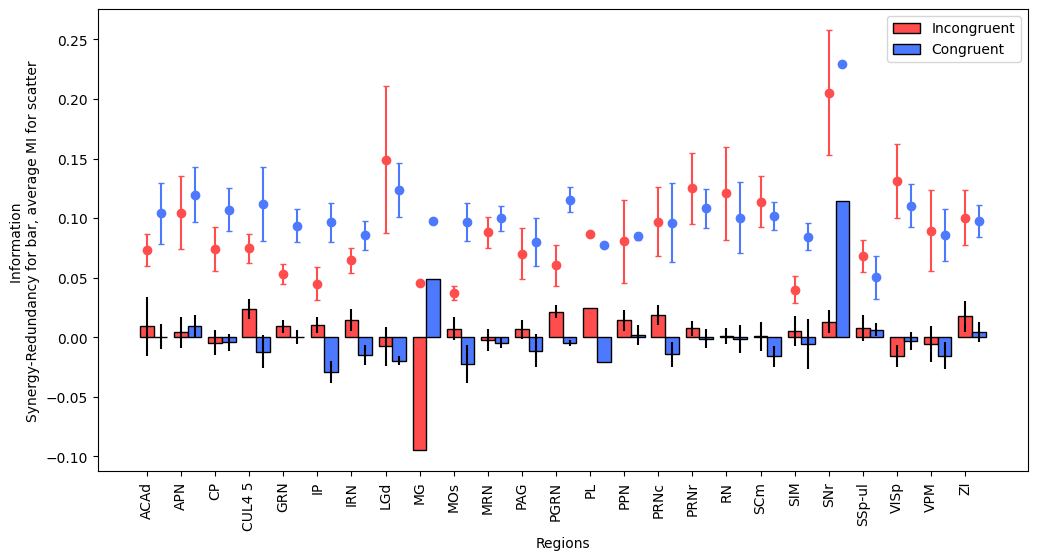

In [234]:
plot_region_wise_tvmi(final_dict)

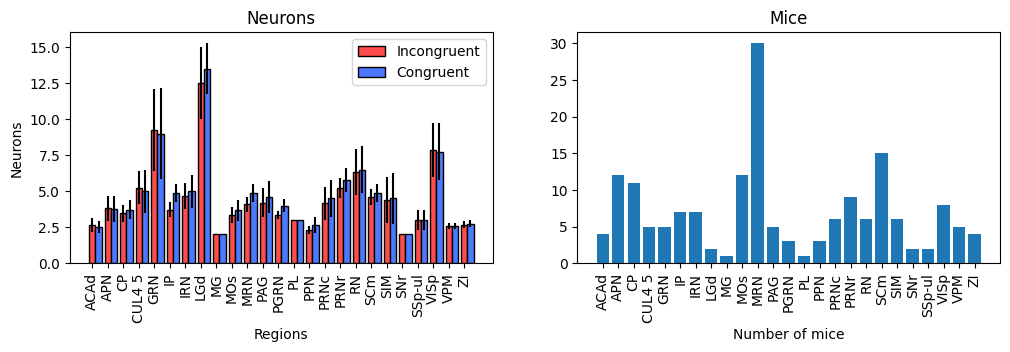

In [235]:
plot_counts(final_dict)

We consider : MG
We skip : MG
We consider : PL


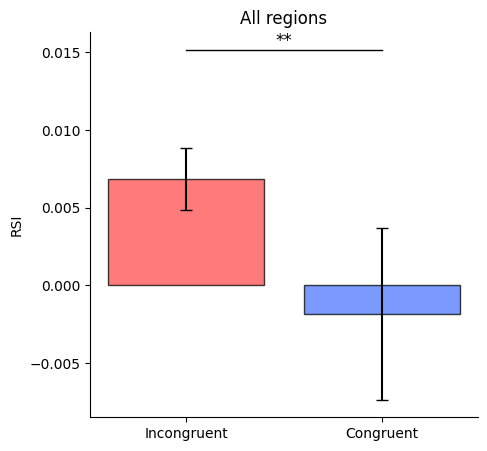

In [236]:
rsi_plots(final_dict)

In [237]:
region_means_count = final_dict["region_means_count"]

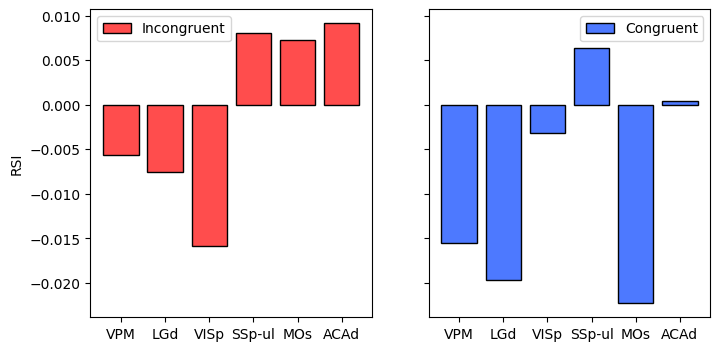

In [215]:
cortical_H_plots(final_dict)

In [216]:
# now we use the other scheme

In [247]:
files_equi = np.sort(glob("../data/generated/mifiltered/equi/*.pkl"))
pairwise_comparisons = collate_pairwise_comparisons(files=files_equi)
final_dict = convert_pairs_into_arrays(pairwise_comparisons)

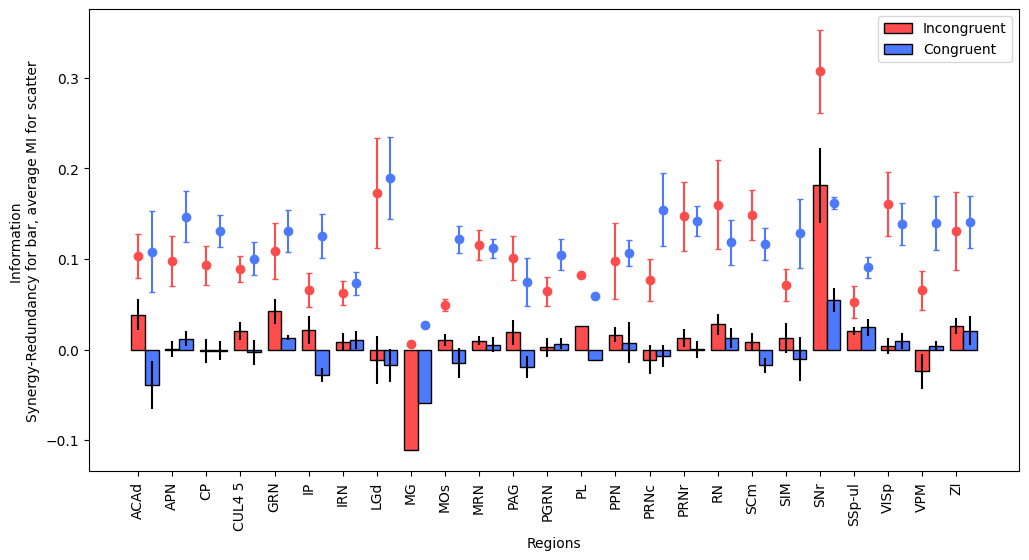

In [248]:
plot_region_wise_tvmi(final_dict)

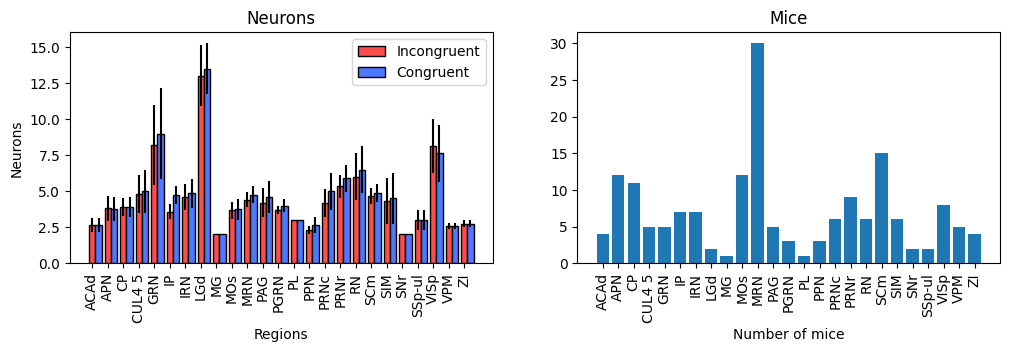

In [249]:
plot_counts(final_dict)

We consider : MG
We skip : MG
We consider : PL


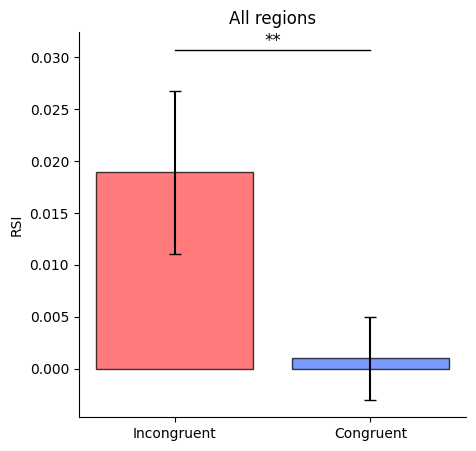

In [250]:
rsi_plots(final_dict)

In [251]:
# nice: now what: we do the cortical hieararchy

In [222]:
# how: keep the criteria, don't use if single insertion and single animal

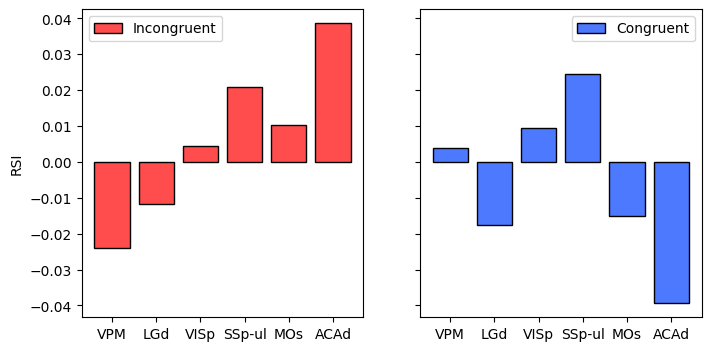

In [223]:
cortical_H_plots(final_dict)

In [263]:
subset_cortical_h[["areas", "index"]]

,areas,index
60,VPM,0
17,LGd,1
53,VISp,2
20,MG,3
44,SSp-ul,4
29,PL,5
22,MOs,6
0,ACAd,7
